PROJETO ANÁLISE EXPLORATÓRIA DE DADOS
ALUNA: DENISE MARIA DE ASSIS ARAUJO Id: 1629014
CURSO: CAIXAVERSO - FC | Analista Dados - I 

Objetivo: O objetivo desse projeto será de analisar os dados de vendas de um supermercado gerando assim ideias que auxiliem nas decisões da empresa. 

Os dados incluem:
- Data da venda
- Produto
- Categoria
- Preço
- Quantidade
- Desconto
- Total da venda
- Idade do cliente
- Renda do cliente


1º PASSO - INSTALAR E IMPORTAR BIBLIOTECA

In [ ]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2º PASSO - LER O ARQUIVO DE DADOS

In [ ]:
df = pd.read_csv("vendas_supermercado_com_cliente.csv")
#Utilizo o  `read_csv()` para ler o arquivo no formato CSV e transformá-lo em um DataFrame do pandas.

3º PASSO - EXPLORAR DADOS E TRATAR TIPOS INCORRETOS. 

ETAPA A - VISÃO GERAL DO DATASET

In [ ]:
df.head()
# Agora utilizo o 'head' para conferir, visualizando as primeiras linhas.

,Data,Produto,Categoria,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda
0,2023-01-01,Maçãs,Alimentos Frescos,16.46,10,0.0,164.60,49,2715.61
1,2023-01-01,Bananas,Alimentos Frescos,2.39,4,0.0,9.56,29,2280.15
2,2023-01-01,Laranjas,Alimentos Frescos,8.38,5,0.0,41.90,67,4419.56
3,2023-01-01,Tomates,Alimentos Frescos,2.03,15,0.0,30.45,29,3809.17
4,2023-01-01,Alface,Alimentos Frescos,37.14,14,0.0,519.96,24,1013.42


In [ ]:
df.shape
#Utilizo o `shape` para mostrar a quantidade de linhas e colunas do conjunto de dados.

(20075, 9)

In [ ]:
df.info()        # tipos de dados e valores nulos
#Aqui já consigo ver que a data está com o tipo de dado "object", ou seja, texto, e para trabalhar com datas é necessário que o tipo seja "datetime". 
#Então, preciso converter a coluna "Data" para o tipo datetime.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20075 entries, 0 to 20074
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Data         20075 non-null  object 
 1   Produto      20075 non-null  object 
 2   Categoria    20075 non-null  object 
 3   Preço        20075 non-null  float64
 4   Quantidade   20075 non-null  int64  
 5   Desconto     20075 non-null  float64
 6   Total_Venda  20075 non-null  float64
 7   Idade        20075 non-null  int64  
 8   Renda        20075 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB


In [16]:
df.describe()
#Fazendo as estatísticas básicas para ter ideia dos valores. 

,Data,Preço,Quantidade,Desconto,Total_Venda,Idade,Renda,Ano,Mes,Dia
count,20075,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.000000,20075.0,20075.000000,20075.000000
mean,2023-07-02 00:00:00,25.577109,10.007671,0.039760,245.901736,45.992827,2999.034265,2023.0,6.526027,15.720548
min,2023-01-01 00:00:00,1.000000,1.000000,0.000000,0.910200,18.000000,1000.380000,2023.0,1.000000,1.000000
25%,2023-04-02 00:00:00,13.260000,5.000000,0.000000,75.604500,32.000000,1993.625000,2023.0,4.000000,8.000000
50%,2023-07-02 00:00:00,25.660000,10.000000,0.000000,186.320000,46.000000,2998.830000,2023.0,7.000000,16.000000
75%,2023-10-01 00:00:00,37.770000,15.000000,0.000000,370.040000,60.000000,4007.675000,2023.0,10.000000,23.000000
max,2023-12-31 00:00:00,49.990000,19.000000,0.500000,949.050000,74.000000,4999.760000,2023.0,12.000000,31.000000
std,NaN,14.115988,5.488450,0.085011,207.773694,16.482103,1159.717376,0.0,3.447937,8.796466


ETAPA B - CORREÇÃO DE TIPOS DE DADOS

In [11]:
#CONVERSÃO DE DATA (passou data de string para tempo)
df["Data"] = pd.to_datetime(df["Data"])
#Necessária pois há perguntas sobre meses e dias da semana. 

4º PASSO - VERIFICAÇÃO E TRATAMENTO DE VALORES AUSENTES

In [13]:
df.isnull().sum()
#Verificando se há valores nulos no conjunto porque se existissem teriamos que tratar antes de analisar. 
#Como o resultado é zero, não há valores nulos, então podemos prosseguir com a análise.


Data           0
Produto        0
Categoria      0
Preço          0
Quantidade     0
Desconto       0
Total_Venda    0
Idade          0
Renda          0
dtype: int64

5º PASSO - EXTRAÇÃO DE PARTES E CRIAÇÃO DE VARIÁVEIS NOVAS

In [ ]:
#EXTRAÇÃO DE COMPONENTES DE DATA, CRIANDO COLUNAS PARA ANO, MÊS, DIA E DIA DA SEMANA. 
df["Ano"] = df["Data"].dt.year
df["Mes"] = df["Data"].dt.month
df["Dia"] = df["Data"].dt.day
df["Dia_Semana"] = df["Data"].dt.day_name()


6º PASSO - RESPONDENDO AS PERGUNTAS COM FERRAMENTAS COMO SELEÇÃO FILTROS E AGRUPAMENTO DE DADOS


LISTA DE EXERCÍCIOS

Pergunta 1: Quais foram as categorias produtos mais vendidos e em quais meses eles tiveram o maior pico de vendas?

In [ ]:
#ETAPA A, B e C - AGRUPO, OPERO COM OS DADOS E CRIO NOVAS VÁRIAVEIS DERIVADAS DE OPERAÇÕES COM DADOS AGRUPADOS. 
#Agrupamento de categoria com o somatório da quantidade vendida para cada categoria, ordenando do maior para o menor para obtermos as categorias mais vendidas.
#Criação de uma váriavel para armazenar esse resultado.
categorias_vendas = (
    df.groupby("Categoria")["Quantidade"].sum().sort_values(ascending=False)
)

categorias_vendas

Categoria
Alimentos Frescos              54755
Produtos de Mercearia          21857
Laticínios e Ovos              18602
Produtos de Limpeza            18448
Produtos de Higiene Pessoal    18374
Bebidas                        18206
Pet Shop                       18081
Congelados                     18051
Utilidades Domésticas          14530
Name: Quantidade, dtype: int64

Text(0.5, 1.0, 'Total de Vendas por Categoria')

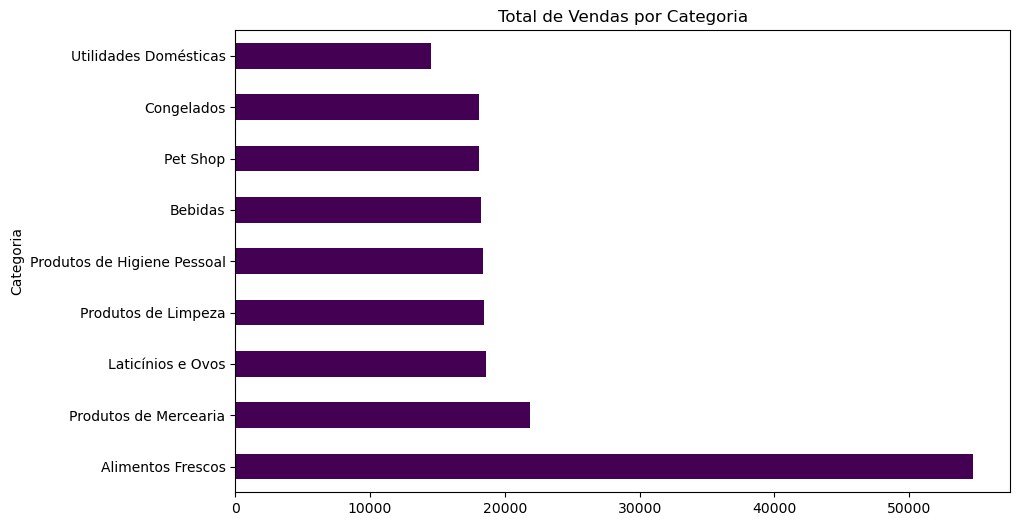

In [43]:
#Criação de grafico para visualizar o resultado.
 
categorias_vendas.plot(kind="barh", figsize=(10, 6), colormap="viridis")
plt.title("Total de Vendas por Categoria")

In [30]:
# Faço um grupamento com as 2 colunas, categoria e mês, somando as quantidades vendidas para cada categoria em cada mês. 
# Faço o reset_index para transformar o resultado em um DataFrame e facilitar a visualização.
#Crio uma variável para armazenar esse resultado.
vendas_categoria_mes = (
    df.groupby(["Categoria","Mes"])["Quantidade"]
    .sum()
    .reset_index()

)
vendas_categoria_mes

,Categoria,Mes,Quantidade
0,Alimentos Frescos,1,4595
1,Alimentos Frescos,2,4199
2,Alimentos Frescos,3,4832
3,Alimentos Frescos,4,4499
4,Alimentos Frescos,5,4474
...,...,...,...
103,Utilidades Domésticas,8,1227
104,Utilidades Domésticas,9,1182
105,Utilidades Domésticas,10,1290
106,Utilidades Domésticas,11,1062


In [29]:
# Crio uma nova variável para armazenar o resultado do pico de vendas, ou seja, o mês em que cada categoria teve a maior quantidade vendida.
# O idxmax retorna com o índice do valor máximo para cada categoria, e o loc é usado para acessar as linhas correspondentes a esses índices 
pico_vendas = vendas_categoria_mes.loc[
    vendas_categoria_mes.groupby("Categoria")["Quantidade"].idxmax()
]

pico_vendas.sort_values("Quantidade", ascending=False)

#RESPOSTA FINAL:
#Assim eu respondo claramente as categorias de produtos mais vendidos e em qual mês cada uma delas teve seu maor pico de vendas. 
# resultando em um DataFrame que mostra o mês de maior venda para cada categoria.

,Categoria,Mes,Quantidade
2,Alimentos Frescos,3,4832
95,Produtos de Mercearia,12,1950
38,Laticínios e Ovos,3,1681
12,Bebidas,1,1651
81,Produtos de Limpeza,10,1650
33,Congelados,10,1649
64,Produtos de Higiene Pessoal,5,1641
53,Pet Shop,6,1586
107,Utilidades Domésticas,12,1308


<Axes: xlabel='Mes', ylabel='Quantidade'>

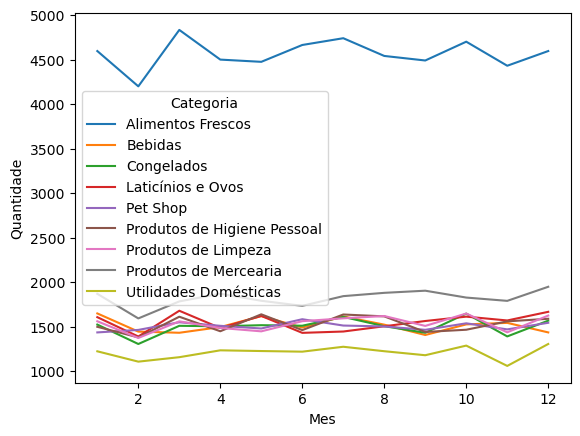

In [48]:
#Crio um gráfico para visualizar o resultado do pico de vendas por categoria.
sns.lineplot(
    data=vendas_categoria_mes,
    x="Mes",
    y="Quantidade",
    hue="Categoria"
)

PERGUNTA 2: Qual a média de vendas diárias por categoria de produto?

In [58]:
#Primeiro eu calculo o valor total vendido por categoria em cada dia.
vendas_diarias = (
    df.groupby(["Categoria","Data"])["Total_Venda"]
    .sum()
    .reset_index()
)
#Agora eu calculo a média por categoria, sempre ordenando do maior para o menor.
media_diaria_categoria = (
    vendas_diarias.groupby("Categoria")["Total_Venda"]
    .mean()
    .sort_values(ascending=False)
)

media_diaria_categoria

Categoria
Alimentos Frescos              3740.573855
Produtos de Mercearia          1451.105881
Laticínios e Ovos              1260.165676
Bebidas                        1244.915513
Produtos de Limpeza            1226.153029
Pet Shop                       1206.387844
Produtos de Higiene Pessoal    1205.587619
Congelados                     1204.712693
Utilidades Domésticas           984.993361
Name: Total_Venda, dtype: float64

<Axes: title={'center': 'Média diária de vendas por categoria'}, xlabel='Categoria'>

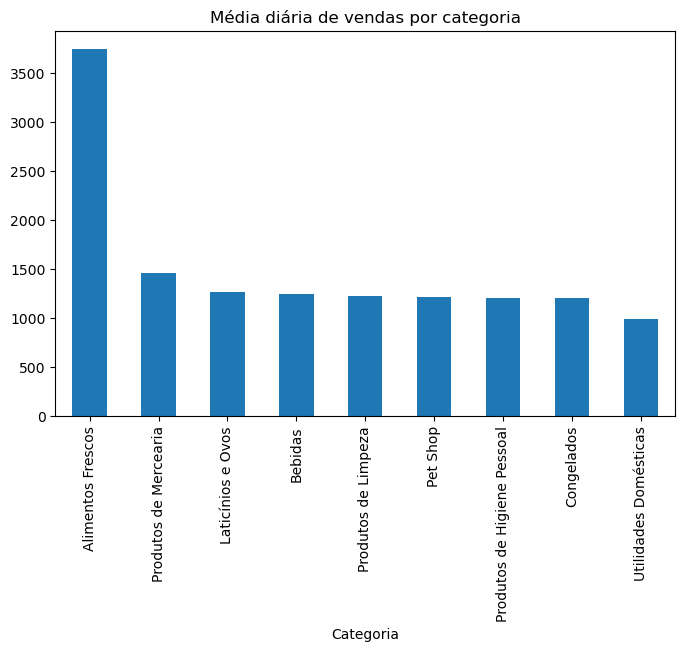

In [62]:
#Criação de gráfico para visualizar a média diária de vendas por categoria.
media_diaria_categoria.plot(
    kind="bar",
    figsize=(8,5),
    title="Média diária de vendas por categoria"
)

PERGUNTA 3:  Quais produtos apresentam a maior sazonalidade nas vendas (ex.: frutas e vegetais,
#sorvetes)?

In [65]:
#Para identificar sazonalidade nas vendas, analisei a variação das vendas mensais de cada produto ao longo do ano.
#Utilizei o coeficiente de variação (CV). O CV é calculado dividindo o desvio padrão pela média das vendas.
# Isso permite comparar a instabilidade das vendas entre produtos diferentes, independentemente do volume total vendido.
#Produtos com maior coeficiente de variação apresentam maior sazonalidade, ou seja, suas vendas variam mais ao longo dos meses.

#VENDAS MENSAIS POR PRODUTO
vendas_produto_mes = (
    df.groupby(["Produto", "Mes"])["Quantidade"]
    .sum()
    .reset_index()
)

vendas_produto_mes

,Produto,Mes,Quantidade
0,Alface,1,346
1,Alface,2,286
2,Alface,3,350
3,Alface,4,299
4,Alface,5,259
...,...,...,...
655,Óleo,8,284
656,Óleo,9,304
657,Óleo,10,274
658,Óleo,11,309


In [66]:
#MÉDIA E DESVIO PADRÃO DAS VENDAS MENSAIS
estatisticas_produto = (
    vendas_produto_mes.groupby("Produto")["Quantidade"]
    .agg(["mean", "std"])
)

estatisticas_produto

,mean,std
Produto,,
Alface,316.000000,34.499012
Amaciantes,302.416667,24.934308
Arroz,295.666667,26.424277
Atum,316.666667,35.780475
Azeite,304.750000,26.981896
Bananas,290.083333,27.483742
Brinquedos para pets,287.166667,26.740617
Carne bovina,306.166667,22.044720
Carne suína,300.500000,31.370223


In [67]:
#CALCULANDO O COEFICIENTE DE VARIAÇÃO
estatisticas_produto["coef_variacao"] = (
    estatisticas_produto["std"] / estatisticas_produto["mean"]
)

estatisticas_produto

,mean,std,coef_variacao
Produto,,,
Alface,316.000000,34.499012,0.109174
Amaciantes,302.416667,24.934308,0.082450
Arroz,295.666667,26.424277,0.089372
Atum,316.666667,35.780475,0.112991
Azeite,304.750000,26.981896,0.088538
Bananas,290.083333,27.483742,0.094744
Brinquedos para pets,287.166667,26.740617,0.093119
Carne bovina,306.166667,22.044720,0.072002
Carne suína,300.500000,31.370223,0.104393


In [68]:
#RESPOSTA FINAL - IDENTIFICANDO OS PRODUTOS COM MAIOR SAZONALIDADE
sazonalidade = (
    estatisticas_produto["coef_variacao"]
    .sort_values(ascending=False)
)

sazonalidade

Produto
Croissants                                         0.156031
Sabão em pó                                        0.147682
Ovos                                               0.138036
Pão integral                                       0.137314
Pratos prontos congelados                          0.136352
Produtos descartáveis (pratos, copos, talheres)    0.127617
Shampoos                                           0.127266
Sabonetes                                          0.126350
Esponjas                                           0.124738
Vinhos                                             0.121808
Sucos                                              0.119217
Farinha                                            0.117481
Vegetais congelados                                0.115069
Óleo                                               0.114884
Atum                                               0.112991
Creme dental                                       0.112873
Sorvetes                        

<Axes: title={'center': 'Top 10 Produtos com Maior Sazonalidade'}, ylabel='Produto'>

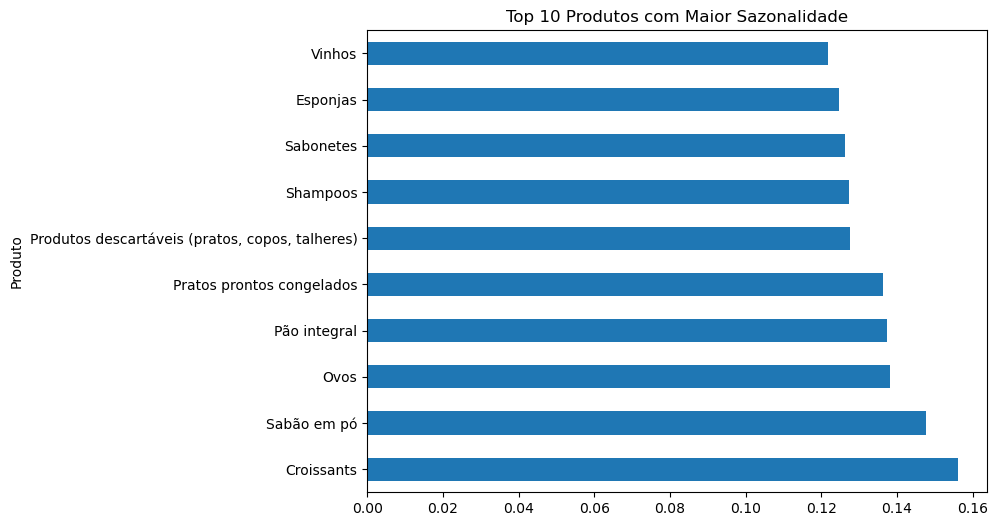

In [69]:
#Crio um gráfico os 10 produtos com maior sazonalidade.
sazonalidade.head(10).plot(
    kind="barh",
    figsize=(8,6),
    title="Top 10 Produtos com Maior Sazonalidade"
)   


PERGUNTA 4 - Quais as faixas etárias contribuíram mais para as vendas totais? Para responder essa pergunta, crie uma coluna com a faixa etária, considerando: entre 18 e 35 (jovem), entre 36 e 59 (adulto) e acima de 60 anos (idoso)


In [ ]:
#FAIXA ETÁRIA
def faixa_etaria(idade):

    if idade >= 18 and idade <= 35:
        return "Jovem"

    elif idade >= 36 and idade <= 59:
        return "Adulto"

    else:
        return "Idoso"


df["Faixa_Etaria"] = df["Idade"].apply(faixa_etaria)

df.head()

In [ ]:
vendas_faixa = (
    df.groupby("Faixa_Etaria")["Total_Venda"]
    .sum()
    .sort_values(ascending=False)
)

vendas_faixa
#Aqui eu analiso qual o grupo contribui mais para o faturammento total. 

Faixa_Etaria
Adulto    2.102042e+06
Jovem     1.537183e+06
Idoso     1.297252e+06
Name: Total_Venda, dtype: float64

In [ ]:
media_por_cliente = (
    df.groupby("Faixa_Etaria")["Total_Venda"]
    .mean()
    .sort_values(ascending=False)
)

media_por_cliente
#Nesse tópico eu analiso qual o grupo tende a gastar mais por compra.

Faixa_Etaria
Adulto    247.794621
Idoso     247.331211
Jovem     242.190543
Name: Total_Venda, dtype: float64

In [ ]:
clientes_por_faixa = df["Faixa_Etaria"].value_counts()

clientes_por_faixa
#E aqui eu verifico a distribuição de meus clientes pelaa faixa etária. Boa ideia para conhecer seus clientes. 


Faixa_Etaria
Adulto    8483
Jovem     6347
Idoso     5245
Name: count, dtype: int64

PERGUNTA 5 - Qual é a relação entre a idade dos clientes e a categoria de produto mais vendida para cada?

In [ ]:
idade_categoria = (
    df.groupby(["Faixa_Etaria","Categoria"])["Quantidade"]
    .sum()
)

idade_categoria

Faixa_Etaria  Categoria                  
Adulto        Alimentos Frescos              23212
              Bebidas                         7491
              Congelados                      7499
              Laticínios e Ovos               7875
              Pet Shop                        7989
              Produtos de Higiene Pessoal     7812
              Produtos de Limpeza             7497
              Produtos de Mercearia           9622
              Utilidades Domésticas           6012
Idoso         Alimentos Frescos              14365
              Bebidas                         5034
              Congelados                      4807
              Laticínios e Ovos               4871
              Pet Shop                        4488
              Produtos de Higiene Pessoal     4557
              Produtos de Limpeza             4800
              Produtos de Mercearia           5365
              Utilidades Domésticas           4053
Jovem         Alimentos Frescos         

In [74]:
#Agora vou identificar a categoria favorita por faixa.
categoria_preferida = idade_categoria.groupby("Faixa_Etaria").idxmax()

categoria_preferida

Faixa_Etaria
Adulto    (Adulto, Alimentos Frescos)
Idoso      (Idoso, Alimentos Frescos)
Jovem      (Jovem, Alimentos Frescos)
Name: Quantidade, dtype: object

PERGUNTA 6 - Qual a distribuição das vendas ao longo dos dias da semana?

In [ ]:
#Primeiro vamos distribuir por valor total de vendas
vendas_semana = (
    df.groupby("Dia_Semana")["Total_Venda"]
    .sum()
    .sort_values(ascending=False)
)

vendas_semana

Dia_Semana
Sunday       722783.6753
Wednesday    710052.0152
Saturday     707984.3710
Friday       707290.9067
Thursday     706311.1298
Monday       695777.3132
Tuesday      686277.9357
Name: Total_Venda, dtype: float64

In [79]:
#E agora para uma análise assertiva vamos distribuir pela média de vendas. 
media_semana = (
    df.groupby("Dia_Semana")["Total_Venda"]
    .mean()
    .sort_values(ascending=False)
)

media_semana

#RESPOSTA FINAL: Com base nessas 2 análises podemos dizer que os dias de maior venda são Domingo e Quarta-feira. vendas_outubro = df[df["Mes"] == 10]["Total_Venda"].sum()



Dia_Semana
Wednesday    248.269935
Sunday       247.953233
Saturday     247.546983
Friday       247.304513
Thursday     246.961933
Monday       243.278781
Tuesday      239.957320
Name: Total_Venda, dtype: float64

PERGUNTA 7: Como as vendas mensais se comparam antes e durante a Black Friday?

In [ ]:
comparacao = df[df["Mes"].isin([10,11])].groupby("Mes")["Total_Venda"].sum()

comparacao
#RESPOSTA FINAL: AO CONTRÁRIO DO ESPERADO, HOUVE QUEDA NAS VENDAS NO MÊS DA BLACK FRIDAY, NOVEMBRO. 

Mes
10    416884.8516
11    385743.3809
Name: Total_Venda, dtype: float64

PERGUNTA 8: Qual é o ticket médio (valor médio das vendas) por faixa etária e como ele varia entre
diferentes categorias de produto?

In [91]:
ticket_medio = (
    df.groupby(["Faixa_Etaria","Categoria"])["Total_Venda"]
    .mean()
)

ticket_medio

Faixa_Etaria  Categoria                  
Adulto        Alimentos Frescos              253.664059
              Bebidas                        240.421985
              Congelados                     245.670753
              Laticínios e Ovos              249.264281
              Pet Shop                       247.798387
              Produtos de Higiene Pessoal    244.521748
              Produtos de Limpeza            249.264331
              Produtos de Mercearia          242.295457
              Utilidades Domésticas          246.394274
Idoso         Alimentos Frescos              251.970517
              Bebidas                        261.236944
              Congelados                     240.421544
              Laticínios e Ovos              256.349856
              Pet Shop                       234.930971
              Produtos de Higiene Pessoal    240.051339
              Produtos de Limpeza            238.871165
              Produtos de Mercearia          245.313649
      

PERGUNTA 9: Comparando a semana da “Black Friday” com a do Natal, qual semana a empresa teve
melhores desempenhos em relação à média de vendas?


In [95]:
# garantir formato de data
df["Data"] = pd.to_datetime(df["Data"])



In [97]:
# criar coluna semana
df["semana"] = df["Data"].dt.isocalendar().week



In [112]:

novembro = df[df["Mes"] == 11]

vendas_semana_nov = novembro.groupby("semana")["Total_Venda"].sum()

semana_black_friday = vendas_semana_nov.idxmax()
valor_black_friday = vendas_semana_nov.max()

semana_black_friday, valor_black_friday

(np.uint32(45), 101146.4)

In [106]:
#Pico de vendas em dezembro
dezembro = df[df["Mes"] == 12]

vendas_semana_dez = dezembro.groupby("semana")["Total_Venda"].sum()

semana_natal = vendas_semana_dez.idxmax()
valor_natal = vendas_semana_dez.max()

semana_natal, valor_natal

(np.uint32(50), 102536.8)

In [122]:
#Agora eu comparo as 2 semanas
comparacao = pd.DataFrame({
    "Evento": ["Black Friday", "Natal"],
    "Semana": [semana_black_friday, semana_natal],
    "Total_Vendas": [valor_black_friday, valor_natal]
})

comparacao
#RESPOSTA FINAL: Podemos concluir que as vendas na semana do natal foram maiores que as da Black Friday. 

,Evento,Semana,Total_Vendas
0,Black Friday,45,101146.4
1,Natal,50,102536.8


PERGUNTA 10: Qual foi o impacto das promoções (descontos aplicados) nas vendas? Quais produtos tiveram o maior aumento nas vendas durante as promoções?

In [114]:
#Vamos separar os com e sem desconto. 
df["Promocao"] = df["Desconto"] > 0

In [ ]:
#Análise do impacto das promoções
impacto = (
    df.groupby("Promocao")["Quantidade"]
    .mean()
)

impacto

Promocao
False    10.012394
True      9.989713
Name: Quantidade, dtype: float64

In [116]:
impacto_produto = (
    df.groupby(["Produto","Promocao"])["Quantidade"]
    .mean()
)

impacto_produto

Produto       Promocao
Alface        False       10.564014
              True         9.723684
Amaciantes    False       10.006920
              True         9.697368
Arroz         False        9.816609
                            ...    
Vinhos        True         9.171053
Água mineral  False       10.183391
              True         9.486842
Óleo          False       10.034602
              True        10.144737
Name: Quantidade, Length: 110, dtype: float64